## Redes Neuronales Convolucionales con PyTorch

https://youtu.be/yUB9JQQVtoU?si=0iXbjX28g-U1oMDB
https://www.youtube.com/watch?v=NLrQZwnWjvI

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torchvision.datasets as datasets
import torchvision.transforms as T
import matplotlib.pyplot as plt



### Descargar Cifar10 dataset

<img src="cifar10.png">

In [3]:
DATA_PATH = '/media/josh/MyData2SSD/Databases/cifar-10-batches-py'
NUM_TRAIN = 50000
NUM_VAL = 5000
NUM_TEST = 5000
MINIBATCH_SIZE = 64

transform_cifar = T.Compose([
                T.ToTensor(),
                T.Normalize([0.491, 0.482, 0.447], [0.247, 0.243, 0.261])
            ])

# Train dataset
cifar10_train = datasets.CIFAR10(DATA_PATH, train=True, download=True,
                             transform=transform_cifar)
train_loader = DataLoader(cifar10_train, batch_size=MINIBATCH_SIZE, 
                          sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))
#Validation set
cifar10_val = datasets.CIFAR10(DATA_PATH, train=False, download=True,
                           transform=transform_cifar)
val_loader = DataLoader(cifar10_val, batch_size=MINIBATCH_SIZE, 
                        sampler=sampler.SubsetRandomSampler(range(NUM_VAL)))
#Test set
cifar10_test = datasets.CIFAR10(DATA_PATH, train=False, download=True, 
                            transform=transform_cifar)
test_loader = DataLoader(cifar10_test, batch_size=MINIBATCH_SIZE,
                        sampler=sampler.SubsetRandomSampler(range(NUM_VAL, len(cifar10_test))))

100.0%
c:\Users\baldj\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
cifar10_train

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: /media/josh/MyData2SSD/Databases/cifar-10-batches-py
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.491, 0.482, 0.447], std=[0.247, 0.243, 0.261])
           )

In [5]:
test_loader.dataset

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: /media/josh/MyData2SSD/Databases/cifar-10-batches-py
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.491, 0.482, 0.447], std=[0.247, 0.243, 0.261])
           )

### Usar GPUs

In [6]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(device)

cpu


### Mostrar imágenes

La imagen muestreada representa un: automobile


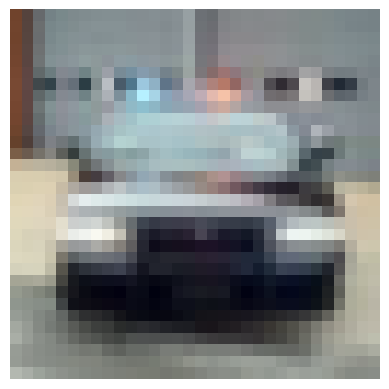

In [13]:
classes = test_loader.dataset.classes
def plot_figure(image):
    plt.imshow(np.transpose(image,(1,2,0)))
    plt.axis('off')
    plt.show()

rnd_sample_idx = np.random.randint(len(test_loader))
print(f'La imagen muestreada representa un: {classes[test_loader.dataset[rnd_sample_idx][1]]}')
image = test_loader.dataset[rnd_sample_idx][0]
image = (image - image.min()) / (image.max() -image.min() )
plot_figure(image)


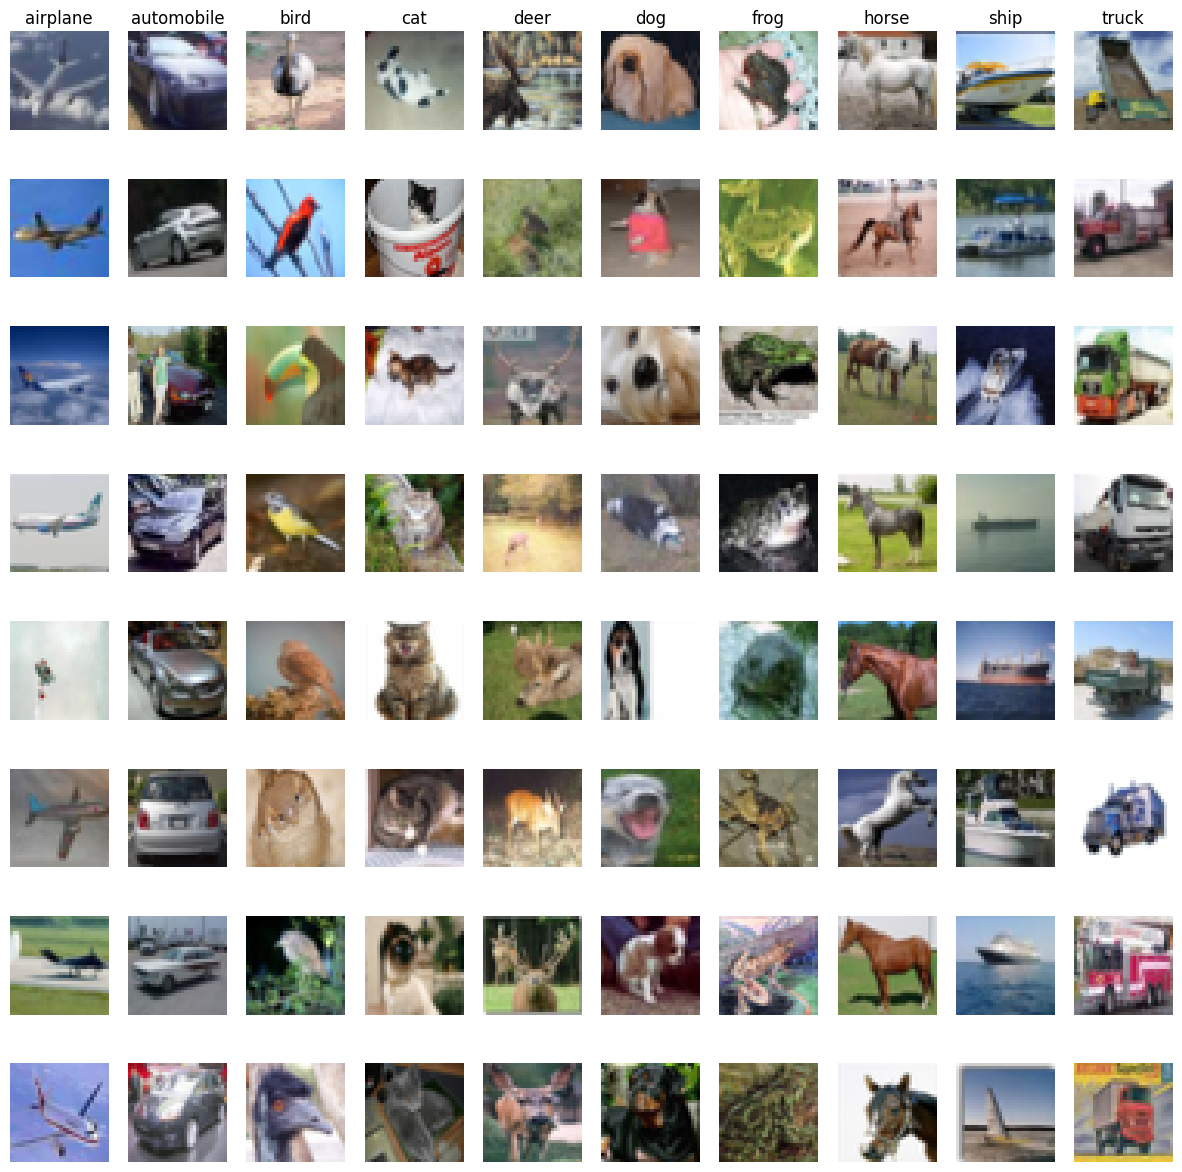

In [16]:
def plot_cifar10_grid():
    classes = test_loader.dataset.classes
    total_samples = 8
    plt.figure(figsize=(15,15))
    for label, sample in enumerate(classes):
        class_idxs = np.flatnonzero(label == np.array(test_loader.dataset.targets))
        sample_idxs = np.random.choice(class_idxs, total_samples, replace = False)
        for i, idx in enumerate(sample_idxs):
            plt_idx = i*len(classes) + label + 1
            plt.subplot(total_samples, len(classes), plt_idx)
            plt.imshow(test_loader.dataset.data[idx])
            plt.axis('off')
            
            if i == 0: plt.title(sample)
    plt.show()

plot_cifar10_grid() 

### Calcular accuracy


In [17]:
for i, (x,y) in enumerate(test_loader):
    print(i, x.shape, y.shape)

0 torch.Size([64, 3, 32, 32]) torch.Size([64])
1 torch.Size([64, 3, 32, 32]) torch.Size([64])
2 torch.Size([64, 3, 32, 32]) torch.Size([64])
3 torch.Size([64, 3, 32, 32]) torch.Size([64])
4 torch.Size([64, 3, 32, 32]) torch.Size([64])
5 torch.Size([64, 3, 32, 32]) torch.Size([64])
6 torch.Size([64, 3, 32, 32]) torch.Size([64])
7 torch.Size([64, 3, 32, 32]) torch.Size([64])
8 torch.Size([64, 3, 32, 32]) torch.Size([64])
9 torch.Size([64, 3, 32, 32]) torch.Size([64])
10 torch.Size([64, 3, 32, 32]) torch.Size([64])
11 torch.Size([64, 3, 32, 32]) torch.Size([64])
12 torch.Size([64, 3, 32, 32]) torch.Size([64])
13 torch.Size([64, 3, 32, 32]) torch.Size([64])
14 torch.Size([64, 3, 32, 32]) torch.Size([64])
15 torch.Size([64, 3, 32, 32]) torch.Size([64])
16 torch.Size([64, 3, 32, 32]) torch.Size([64])
17 torch.Size([64, 3, 32, 32]) torch.Size([64])
18 torch.Size([64, 3, 32, 32]) torch.Size([64])
19 torch.Size([64, 3, 32, 32]) torch.Size([64])
20 torch.Size([64, 3, 32, 32]) torch.Size([64])
21

In [18]:
def accuracy(model, loader):
    num_correct = 0
    num_total = 0
    model.eval()
    model = model.to(device=device)
    with torch.no_grad():
        for xi, yi in loader:
            xi = xi.to(device=device, dtype = torch.float32)
            yi = yi.to(device=device, dtype = torch.long)
            scores = model(xi) 
            _, pred = scores.max(dim=1) 
            num_correct += (pred == yi).sum() 
            num_total += pred.size(0)
        return float(num_correct)/num_total   

### Loop de entrenamiento

In [19]:
def train(model, optimiser, epochs=100):
    model = model.to(device=device)
    for epoch in range(epochs):
        for i, (xi, yi) in enumerate(train_loader):
            model.train()
            xi = xi.to(device=device, dtype=torch.float32)
            yi = yi.to(device=device, dtype=torch.long)
            scores = model(xi)
            cost = F.cross_entropy(input= scores, target=yi)
            optimiser.zero_grad()           
            cost.backward()
            optimiser.step()              
        acc = accuracy(model, val_loader) 
        print(f'Epoch: {epoch}, costo: {cost.item()}, accuracy: {acc},')

### Sequential linear

In [20]:
hidden1 = 256 
hidden = 256
lr = 0.001
epochs = 10
model1 = nn.Sequential(nn.Flatten(),
                       nn.Linear(in_features=32*32*3, out_features=hidden1), nn.ReLU(),
                       nn.Linear(in_features=hidden1, out_features=hidden), nn.ReLU(),
                       nn.Linear(in_features=hidden, out_features=10))
optimiser = torch.optim.Adam(model1.parameters(), lr=lr)

In [21]:
train(model1, optimiser, epochs)

Epoch: 0, costo: 1.6000784635543823, accuracy: 0.477,
Epoch: 1, costo: 1.6357122659683228, accuracy: 0.5042,
Epoch: 2, costo: 1.5876165628433228, accuracy: 0.5144,
Epoch: 3, costo: 1.3976269960403442, accuracy: 0.5216,
Epoch: 4, costo: 1.1958839893341064, accuracy: 0.5116,
Epoch: 5, costo: 1.0988681316375732, accuracy: 0.5206,
Epoch: 6, costo: 0.9325785040855408, accuracy: 0.5324,
Epoch: 7, costo: 0.9376741647720337, accuracy: 0.5216,
Epoch: 8, costo: 1.4494110345840454, accuracy: 0.523,
Epoch: 9, costo: 1.2787880897521973, accuracy: 0.5368,


### Sequential CNN

In [22]:
channel1 = 16
channel2 = 32
epochs = 10
lr = 0.0001
modelCNN1 = nn.Sequential(nn.Conv2d(in_channels=3, out_channels=channel1, 
                                   kernel_size=3, padding=1),
                          nn.ReLU(),
                          nn.Conv2d(in_channels=channel1, out_channels=channel2,
                                    kernel_size= 3, padding=1),
                          nn.ReLU(),
                          nn.MaxPool2d(2, 2),
                          nn.Flatten(),
                          nn.Linear(in_features=16*16*channel2, out_features=10)                        
                                   )
optimiser = torch.optim.Adam(modelCNN1.parameters(), lr)

In [23]:
train(modelCNN1, optimiser, epochs)

Epoch: 0, costo: 1.7001540660858154, accuracy: 0.4904,
Epoch: 1, costo: 1.2592873573303223, accuracy: 0.5362,
Epoch: 2, costo: 1.455058217048645, accuracy: 0.5546,
Epoch: 3, costo: 1.221134901046753, accuracy: 0.583,
Epoch: 4, costo: 0.9640594720840454, accuracy: 0.5834,
Epoch: 5, costo: 1.134189486503601, accuracy: 0.6024,
Epoch: 6, costo: 0.8239881992340088, accuracy: 0.613,
Epoch: 7, costo: 1.0034064054489136, accuracy: 0.619,
Epoch: 8, costo: 0.8098369240760803, accuracy: 0.6248,
Epoch: 9, costo: 0.8500558137893677, accuracy: 0.631,


### OOP 

In [24]:
class CNN_class1(nn.Module):
    def __init__(self, in_channel, channel1, channel2):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = in_channel, out_channels = channel1,
                              kernel_size=3, padding = 1)
        self.conv2 = nn.Conv2d(in_channels = channel1, out_channels = channel2,
                              kernel_size=3, padding=1)
        self.max_pool = nn.MaxPool2d(2,2)
        self.fc = nn.Linear(in_features=16*16*channel2, out_features=10)
        self.flatten = nn.Flatten()
    def forward(self, x):
        x = F.relu(self.conv2(F.relu(self.conv1(x))))
        x = self.max_pool(x)
        x = self.flatten(x)
        return self.fc(x)

In [25]:
channel1 = 16
channel2 = 32
epochs = 10
lr = 0.0001
modelCNN2 = CNN_class1(3, channel1, channel2)
optimiser = torch.optim.Adam(modelCNN2.parameters(), lr)

In [26]:
train(modelCNN2, optimiser, epochs)

Epoch: 0, costo: 1.3215481042861938, accuracy: 0.4894,
Epoch: 1, costo: 1.2813578844070435, accuracy: 0.539,
Epoch: 2, costo: 1.5999904870986938, accuracy: 0.5662,
Epoch: 3, costo: 1.0742660760879517, accuracy: 0.577,
Epoch: 4, costo: 0.9962865710258484, accuracy: 0.603,
Epoch: 5, costo: 1.0906871557235718, accuracy: 0.6232,
Epoch: 6, costo: 1.0962862968444824, accuracy: 0.6254,
Epoch: 7, costo: 0.8767489194869995, accuracy: 0.6336,
Epoch: 8, costo: 1.1775641441345215, accuracy: 0.6408,
Epoch: 9, costo: 0.9244989156723022, accuracy: 0.655,


### Un poco más elegante

In [27]:
conv_k_3 = lambda channel1, channel2: nn.Conv2d(channel1, channel2, kernel_size=3, padding=1)

In [28]:
class CNN_class2(nn.Module):
    def __init__(self, in_channel, channel1, channel2):
        super().__init__()
        self.conv1 = conv_k_3(in_channel, channel1)
        nn.init.kaiming_uniform_(self.conv1.weight)

        self.conv2 = conv_k_3(channel1, channel2)
        self.max_pool = nn.MaxPool2d(2,2)
        self.fc = nn.Linear(in_features=16*16*channel2, out_features=10)
        self.flatten = nn.Flatten()
    def forward(self, x):
        x = F.relu(self.conv2(F.relu(self.conv1(x))))
        x = self.max_pool(x)
        x = self.flatten(x)
        return self.fc(x)
    

In [29]:
channel1 = 16
channel2 = 32
epochs = 10
lr = 0.0001
modelCNN3 = CNN_class2(3, channel1, channel2)
optimiser = torch.optim.Adam(modelCNN3.parameters(), lr)

In [30]:
train(modelCNN3, optimiser, epochs)

Epoch: 0, costo: 1.7602589130401611, accuracy: 0.4964,
Epoch: 1, costo: 1.16203773021698, accuracy: 0.5386,
Epoch: 2, costo: 1.282814621925354, accuracy: 0.5778,
Epoch: 3, costo: 1.4715850353240967, accuracy: 0.6012,
Epoch: 4, costo: 1.359919548034668, accuracy: 0.6046,
Epoch: 5, costo: 1.1843661069869995, accuracy: 0.631,
Epoch: 6, costo: 0.7656233310699463, accuracy: 0.6334,
Epoch: 7, costo: 0.4800792634487152, accuracy: 0.6324,
Epoch: 8, costo: 0.9282174706459045, accuracy: 0.6412,
Epoch: 9, costo: 0.7765622735023499, accuracy: 0.6496,


In [31]:
class CNN_class3(nn.Module):
    def __init__(self, in_channel, channel1, channel2):
        super().__init__()
        self.conv1 = conv_k_3(in_channel, channel1)
        self.bn1 = nn.BatchNorm2d(channel1)

        self.conv2 = conv_k_3(channel1, channel2)
        self.bn2 = nn.BatchNorm2d(channel2)
        
        self.max_pool = nn.MaxPool2d(2,2)
        self.fc = nn.Linear(in_features=16*16*channel2, out_features=10)
        self.flatten = nn.Flatten()
    def forward(self, x):
        x = F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x))))))
        x = self.max_pool(x)
        x = self.flatten(x)
        return self.fc(x)

In [32]:
channel1 = 16
channel2 = 32
epochs = 10
lr = 0.0001
modelCNN4 = CNN_class3(3, channel1, channel2)
optimiser = torch.optim.Adam(modelCNN4.parameters(), lr)

In [33]:
train(modelCNN4, optimiser, epochs)

Epoch: 0, costo: 1.1503432989120483, accuracy: 0.5624,
Epoch: 1, costo: 1.2086951732635498, accuracy: 0.6142,
Epoch: 2, costo: 1.121259093284607, accuracy: 0.6294,
Epoch: 3, costo: 1.0609610080718994, accuracy: 0.6516,
Epoch: 4, costo: 0.8121930360794067, accuracy: 0.6454,
Epoch: 5, costo: 1.1542550325393677, accuracy: 0.665,
Epoch: 6, costo: 0.8579796552658081, accuracy: 0.663,
Epoch: 7, costo: 1.0666242837905884, accuracy: 0.6546,
Epoch: 8, costo: 0.4673883318901062, accuracy: 0.6736,
Epoch: 9, costo: 0.2849270701408386, accuracy: 0.6678,


In [34]:
class CNN_class4(nn.Module):
    def __init__(self, in_channel, channel1, channel2):
        super().__init__()
        self.conv1 = conv_k_3(in_channel, channel1)
        self.bn1 = nn.BatchNorm2d(channel1)

        self.conv2 = conv_k_3(channel1, channel2)
        self.bn2 = nn.BatchNorm2d(channel2)
        
        self.max_pool = nn.MaxPool2d(2,2)

    def forward(self, x):
        x = F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x))))))
        return self.max_pool(x)

In [35]:
channel1 = 16
channel2 = 32
channel3 = 64
channel4 = 128
epochs = 10
lr = 0.001
modelCNN5 = nn.Sequential(CNN_class4(3,channel1, channel2),
                          CNN_class4(channel2, channel4, channel4),
                          nn.Flatten(),
                          nn.Linear(in_features=8*8*channel4, out_features=10))

optimiser = torch.optim.Adam(modelCNN5.parameters(), lr)

In [37]:
train(modelCNN5, optimiser, epochs)

Epoch: 0, costo: 0.8967172503471375, accuracy: 0.6608,
Epoch: 1, costo: 0.6834031343460083, accuracy: 0.7074,
Epoch: 2, costo: 0.9364829063415527, accuracy: 0.7272,
Epoch: 3, costo: 0.24898241460323334, accuracy: 0.7706,
Epoch: 4, costo: 0.648505449295044, accuracy: 0.7816,
Epoch: 5, costo: 0.18853017687797546, accuracy: 0.765,
Epoch: 6, costo: 0.38405606150627136, accuracy: 0.7758,
Epoch: 7, costo: 0.4899127781391144, accuracy: 0.799,
Epoch: 8, costo: 0.02404971607029438, accuracy: 0.7846,
Epoch: 9, costo: 0.6976048350334167, accuracy: 0.7828,


In [36]:
accuracy(modelCNN5, test_loader)

0.0822